### ライブラリのインストール

In [1]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

### モデル読み込み

In [2]:
model = YOLO("../models/fashionpedia_9class_with_data_augmentation.pt")

### 画像の読み込み

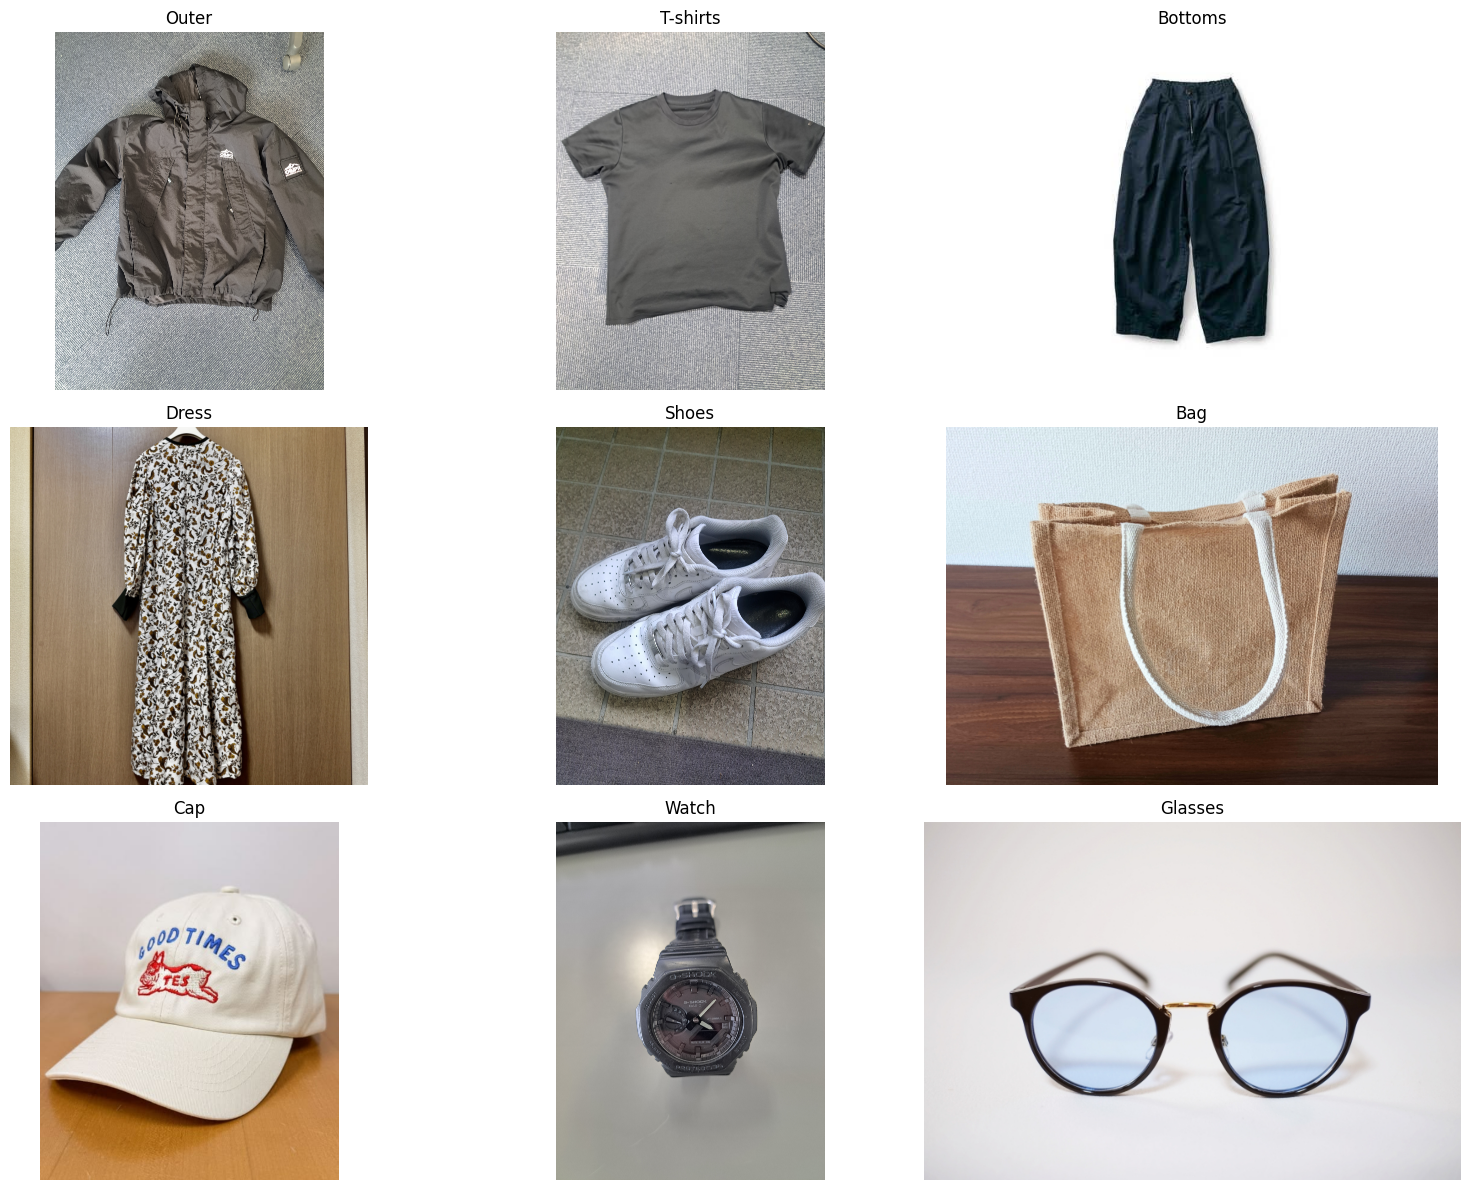

In [3]:
# 1. 画像パスのリスト（8枚分）
image_paths = [
    "input/sample_outer.jpg",             # 0: アウター
    "input/sample_Tshirts.jpg",           # 1: トップス
    "input/sample_bottoms.jpg",           # 2: ボトムス
    "input/sample_dress.jpg",             # 3: ドレス    
    "input/sample_shoes.jpg",             # 4: シューズ
    "input/sample_bag.jpg",               # 5: バッグ　
    "input/sample_cap.jpg",               # 6: 帽子
    "input/sample_watch.jpg",             # 7: 時計
    "input/sample_glasses.jpg",           # 8: メガネ
]

# 画像のタイトル（表示用）
titles = ["Outer", "T-shirts", "Bottoms", "Dress", "Shoes", "Bag", "Cap", "Watch", "Glasses"]

# 2. 画面全体のサイズを設定
plt.figure(figsize=(16, 12))

# 3. ループ処理で9枚の画像を順番に読み込んで配置
for i in range(9):
    # 画像の読み込み
    img = cv2.imread(image_paths[i])
    # BGRからRGBに変換
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 3行 × 3列 の配置エリアを指定 (i + 1 番目の位置)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(titles[i])
    plt.axis("off")  # 枠線と目盛りを非表示

# 隙間を自動調整して綺麗に並べる
plt.tight_layout()

# 画面に表示
plt.show()

### セグメンテーションの実行

In [4]:
# 予測結果を保存するための空のリストを用意
all_results = []

# image_paths には、先ほどの8枚の画像パスが入っている前提です
for i, path in enumerate(image_paths):
    # 1. 画像の読み込みとRGB変換
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 2. 予測の実行（タイトルに合わせてログを出すと分かりやすいです）
    print(f"--- Predicting: {titles[i]} ({path}) ---")
    results = model.predict(
        source=img_rgb,
        conf=0.40,
        save=False
    )
    
    # 3. 配列（リスト）に結果を格納していく
    all_results.append(results)

--- Predicting: Outer (input/sample_outer.jpg) ---

0: 640x480 1 tops, 57.7ms
Speed: 3.7ms preprocess, 57.7ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
--- Predicting: T-shirts (input/sample_Tshirts.jpg) ---

0: 640x480 1 tops, 32.8ms
Speed: 2.4ms preprocess, 32.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
--- Predicting: Bottoms (input/sample_bottoms.jpg) ---

0: 640x544 1 bottoms, 38.6ms
Speed: 1.2ms preprocess, 38.6ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 544)
--- Predicting: Dress (input/sample_dress.jpg) ---

0: 640x640 1 dress, 48.9ms
Speed: 0.9ms preprocess, 48.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)
--- Predicting: Shoes (input/sample_shoes.jpg) ---

0: 640x480 2 shoess, 27.2ms
Speed: 3.0ms preprocess, 27.2ms inference, 18.2ms postprocess per image at shape (1, 3, 640, 480)
--- Predicting: Bag (input/sample_bag.jpg) ---

0: 480x640 1 bag, 36.8ms
Speed: 1.0ms preprocess, 36.8ms infe

### マスク取得

In [5]:
# 8枚分の「純粋な結果オブジェクト」を格納する辞書
processed_results = {}

for i, results in enumerate(all_results):
    # 各画像の最初の要素 [0] を取り出す（これが純粋なマスクやボックスの中身）
    result_object = results[0]
    
    # 画像のタイトル（"T-shirts" や "Shoes" など）をキーにして辞書に保存
    category_name = titles[i]
    processed_results[category_name] = result_object

print("\nすべての結果オブジェクトの読み込みが完了しました！")


すべての結果オブジェクトの読み込みが完了しました！


### マスクを出力

すべての画像のアノテーション処理（描画）が完了しました！


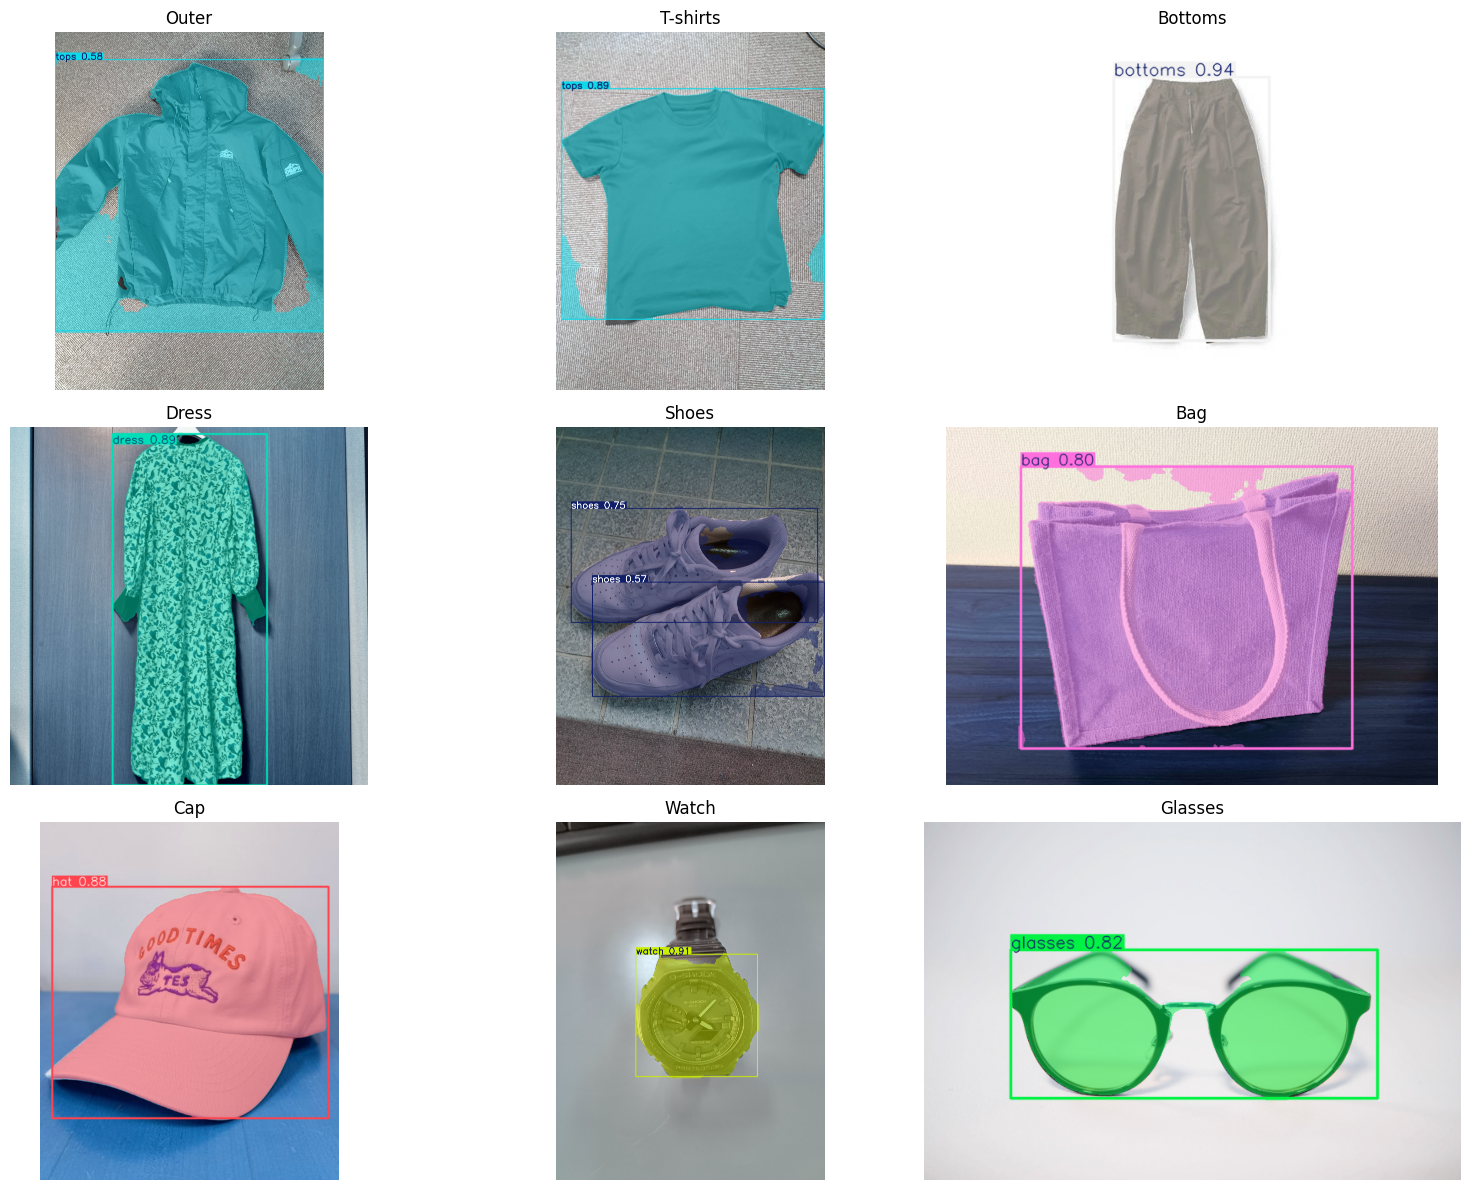

In [7]:
# アノテーション付き画像を格納する新しい辞書
annotated_images = {}

# 前のステップで作った processed_results 辞書をループ
# nameはタイトル（"T-shirts"など）、resultは結果オブジェクト
for name, result in processed_results.items():
    # 予測結果を描画した画像を生成（plotメソッド）
    # plot()はデフォルトでBGRなので、表示用にRGBに変換しておく
    img_bgr = result.plot()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 辞書に保存
    annotated_images[name] = img_rgb

print("すべての画像のアノテーション処理（描画）が完了しました！")

# 画面全体のサイズを設定 (横に4枚並ぶので、横幅を広めの15インチに設定)
plt.figure(figsize=(16, 12))

# タイトルのリストを使って、順番に表示
for i, name in enumerate(titles):
    # アノテーション付き画像を取り出す
    img = annotated_images[name]
    
    # 3行 × 3列 の配置エリアを指定 (i + 1 番目の位置)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(name)  # 画像のタイトルを表示
    plt.axis("off")  # 枠線と目盛りを非表示

# 隙間を自動調整して綺麗に並べる
plt.tight_layout()

# 画面に表示
plt.show()

### マスクを白黒でnumpy形式に変換

In [ ]:
# 1. Tシャツ（リストの2番目、インデックス1）の結果オブジェクトを取得
result_Tshirts = processed_results["T-shirts"]

# 2. マスクが検出されたかチェック
if result_Tshirts.masks is None:
    raise Exception("Tシャツのマスクが検出されませんでした")

# 3. マスクデータをCPUに移動させてNumPy配列に変換
masks_Tshirts = result_Tshirts.masks.data.cpu().numpy()

# 4. 1番目（最大）のマスクを抽出
largest_mask_Tshirts = masks_Tshirts[0]

print("Tシャツのマスク抽出に成功しました！")
print("マスクの形状（Shape）:", largest_mask_Tshirts.shape)

## 背景透過

In [ ]:
mask_Tshirts = (largest_mask_Tshirts * 255).astype(np.uint8)#01の画像を0~255の画像へ変換

image_Tshirts = cv2.imread(image_paths[1])
image_Tshirts_rgb = cv2.cvtColor(image_Tshirts, cv2.COLOR_BGR2RGB)

mask_Tshirts = cv2.resize(
    mask_Tshirts,
    (image_Tshirts_rgb.shape[1], image_Tshirts_rgb.shape[0])
)#マスク画像を元画像のサイズにリサイズ

rgba = cv2.cvtColor(image_Tshirts_rgb, cv2.COLOR_RGB2RGBA)

rgba[:, :, 3] = mask_Tshirts

output_path = "output/transparent.png"

Image.fromarray(rgba).save(output_path)

print("保存完了:", output_path)

In [ ]:
#結果確認
transparent = Image.open(output_path)

plt.figure(figsize=(6,6))
plt.imshow(transparent)
plt.axis("off")

## Gemini解析

### Gemini APIとの連携

In [13]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("GEMINI_API_KEY")

#print(api_key)

### Geminiモデルの初期化

In [14]:
import google.generativeai as genai

available_models = [m.name for m in genai.list_models()]
print(available_models)

/users/tw/takahashi/SmartCloset_AI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_69490/3772955356.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


['models/gemini-2.5-flash', 'models/gemini-2.5-pro', 'models/gemini-2.0-flash', 'models/gemini-2.0-flash-001', 'models/gemini-2.0-flash-lite-001', 'models/gemini-2.0-flash-lite', 'models/gemini-2.5-flash-preview-tts', 'models/gemini-2.5-pro-preview-tts', 'models/gemma-4-26b-a4b-it', 'models/gemma-4-31b-it', 'models/gemini-flash-latest', 'models/gemini-flash-lite-latest', 'models/gemini-pro-latest', 'models/gemini-2.5-flash-lite', 'models/gemini-2.5-flash-image', 'models/gemini-3-pro-preview', 'models/gemini-3-flash-preview', 'models/gemini-3.1-pro-preview', 'models/gemini-3.1-pro-preview-customtools', 'models/gemini-3.1-flash-lite-preview', 'models/gemini-3.1-flash-lite', 'models/gemini-3-pro-image-preview', 'models/gemini-3-pro-image', 'models/nano-banana-pro-preview', 'models/gemini-3.1-flash-image-preview', 'models/gemini-3.1-flash-image', 'models/gemini-3.5-flash', 'models/lyria-3-clip-preview', 'models/lyria-3-pro-preview', 'models/gemini-3.1-flash-tts-preview', 'models/gemini-rob

In [15]:
genai.configure(
    api_key=api_key
)

model_gemini = genai.GenerativeModel(
   "gemini-2.5-flash"
)

### GeminiによるTシャツの解析

In [16]:
prompt = """
この衣服画像を解析してください。

以下のJSON形式のみで返してください。

{
  "category": "",
  "color_primary": "",
  "color_secondary": "",}
  "pattern": "",
  "silhouette": ""
}

ルール:
- color_secondary は無ければ null
- 日本語で出力
- JSON以外を出力しない
"""

img = Image.open(output_path)

response = model_gemini.generate_content(
    [prompt, img],
    generation_config={
        "response_mime_type": "application/json"#出力がMARKDOWN形式になってしまったので明示的に追加
    }
)

print(response.text)

{
  "category": "Tシャツ",
  "color_primary": "ダークグレー",
  "color_secondary": null,
  "pattern": "無地",
  "silhouette": "レギュラーフィット"
}


In [17]:
#出力をjsonとして扱う
import json

metadata = json.loads(response.text)

print(metadata)

{'category': 'Tシャツ', 'color_primary': 'ダークグレー', 'color_secondary': None, 'pattern': '無地', 'silhouette': 'レギュラーフィット'}
